In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import BayesianRidge, LinearRegression
import matplotlib.pyplot as plt
from numpy.linalg import inv
import pytensor as pt
import arviz as az
from scipy.stats import gamma


In [3]:
X_train = pd.read_csv("Spionidae/X_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_train = pd.read_csv("Spionidae/y_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

X_test = pd.read_csv("Spionidae/X_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_test = pd.read_csv("Spionidae/y_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

# X_train = pd.read_csv("X_train_fauna.csv",
#         sep=",",
#         encoding="utf-8")
# y_train = pd.read_csv("y_train_fauna.csv",
#         sep=",",
#         encoding="utf-8")

In [4]:
X_train.shape[1]

48

In [ ]:
X1 = X_train.iloc[:,1]
X2 = X_train.iloc[:,2]
X3 = X_train.iloc[:,3]

X1_test = X_test.iloc[:,1]

X1.shape, X2.shape
y = y_train.values.ravel()
y_test = y_test.values.ravel()
X1.values.shape

(280,)

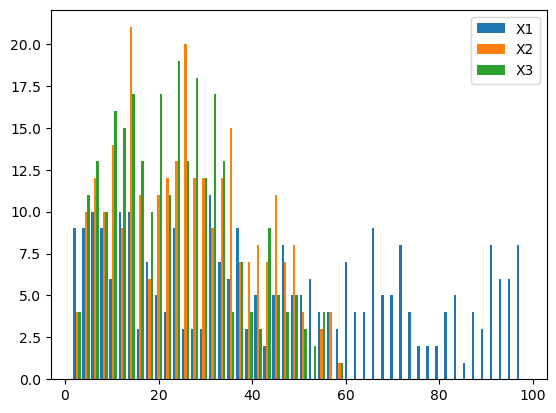

In [ ]:
plt.hist([X1,X2,X3], label=['X1','X2','X3'], bins=50)
plt.legend()

In [ ]:
a1 ,l1, b1 = gamma.fit(X1)
a2, l2, b2 = gamma.fit(X2)
y1, y2, y3 = gamma.fit(y)
np.mean(X1)

44.99264267108422

In [ ]:
#New model
labels = ["Intercept", "x1", "x2", "x1:x2"]
X_train["Intercept"] = np.ones(len(X_train))
# X_train["x1:x2"] = X_train["Al"] * X_train["Fe"]
# reorder columns to be in the same order as labels
df = X_train[labels]
x = df.to_numpy()

KeyError: "['x1', 'x2'] not in index"

In [ ]:
with pm.Model() as model:
    # X1 = X1-np.mean(X1)
    # X2 = X2-np.mean(X2)
    beta1 = pm.Normal("beta_1", mu=np.mean(X1), sigma=np.var(X1)*2)
    beta2 = pm.Normal("beta_2", mu=np.mean(X2), sigma=np.var(X2)*2)
    beta3 = pm.Normal("beta_3", mu=np.mean(X3), sigma=np.var(X3)*2)
    intercept = pm.Normal("intercept", mu=1000, sigma=1000)
    sigma = pm.HalfNormal("sigma", sigma=1)
    # Deterministic relationship
    mu = intercept + beta1 * X1 + beta2*X2 + beta3*X3
    # Likelihood based on observed y
    y_likelihood = pm.Gamma("y_likelihood", mu=mu, sigma=sigma, observed=y+0.0001)
    # mu_transformed = pm.math.sigmoid(mu)  # Logistic function

    # Ensure positive alpha and beta by adding a small offset to avoid invalid parameters
    # alpha = pm.HalfNormal("alpha", sigma=1) * mu_transformed  # Ensuring positive alpha
    # beta = pm.HalfNormal("beta", sigma=1) * (1 - mu_transformed)  # Ensure positive beta

    # Likelihood using Beta distribution
    # y_likelihood = pm.Beta("y_likelihood", alpha=alpha, beta=beta, observed=y)

    # Sampling
    trace = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_1, beta_2, beta_3, intercept, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.
There were 907 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'beta_1'}>,
        <Axes: title={'center': 'beta_2'}>,
        <Axes: title={'center': 'beta_3'}>],
       [<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'sigma'}>, <Axes: >]], dtype=object)

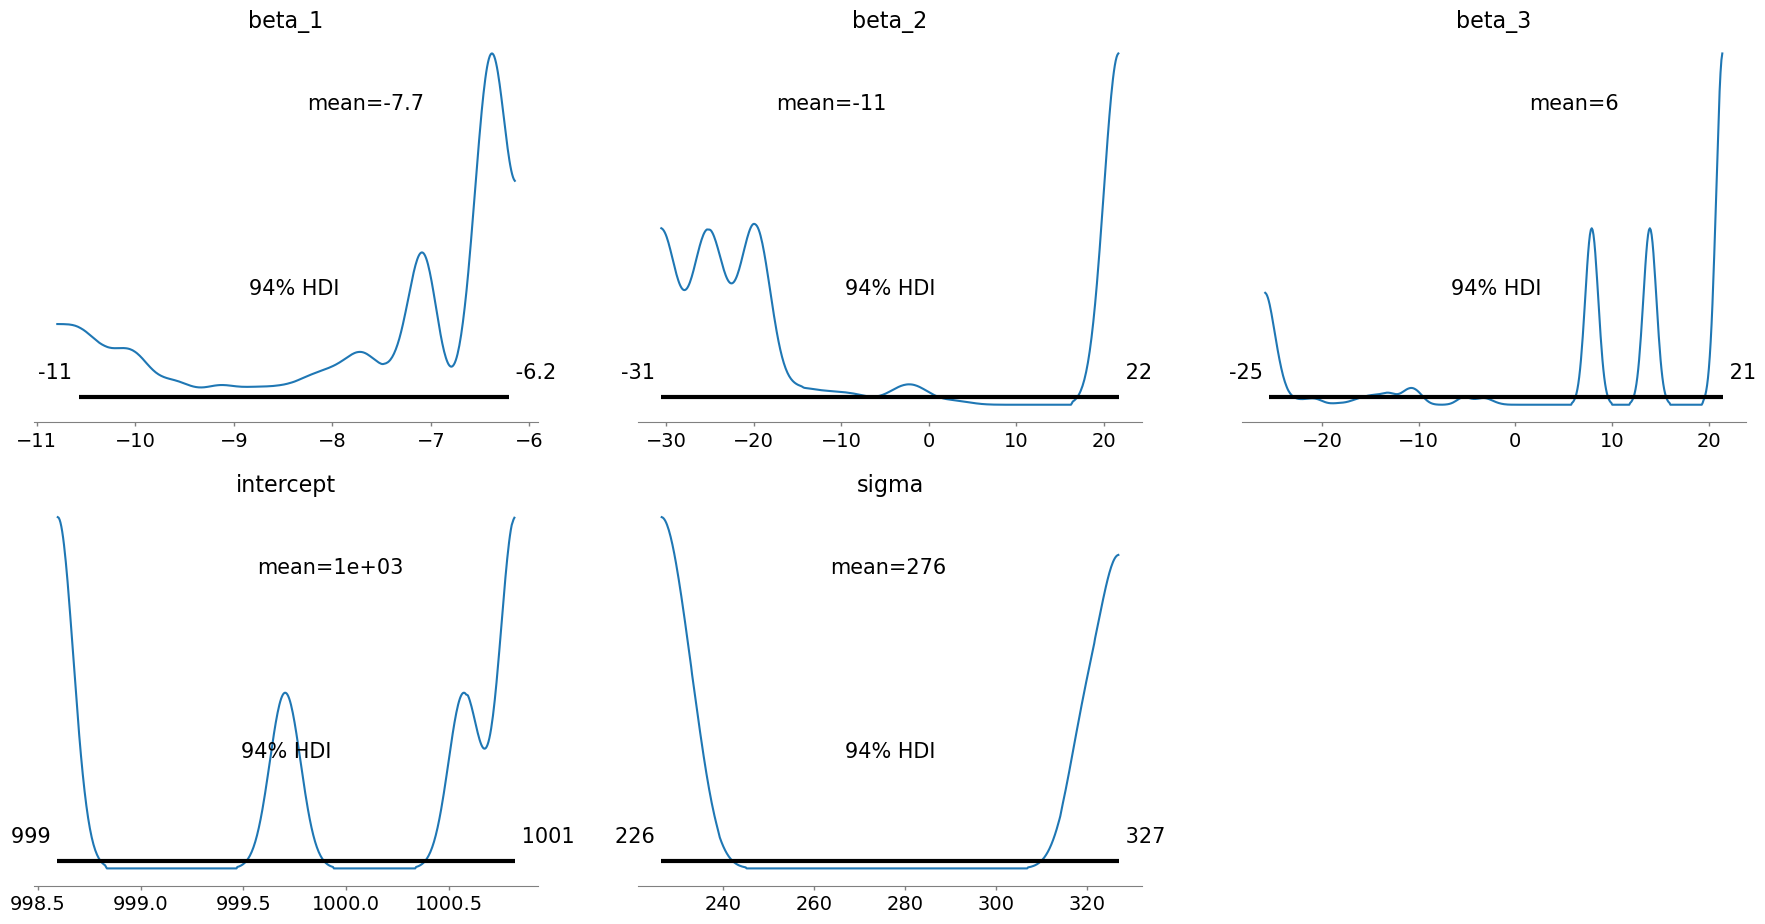

In [ ]:
az.summary(trace)

# Trace plots
# az.plot_trace(trace)
az.plot_posterior(trace)

In [ ]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [ ]:
# with model:
#     posterior_samples = trace.posterior['beta_1'], trace.posterior['intercept']

numCoeff = 3

Xn_test = []
beta_samples = []
for i in range(numCoeff):
    Xtemp = np.asarray(X_test.iloc[:,i+1])
    Xtemp = Xtemp[None, :, None]
    beta = trace.posterior[f'beta_{i+1}'].values
    beta = beta[:, None, :]
    Xtemp = np.repeat(Xtemp, beta.shape[1], axis=2)

    Xn_test.append(Xtemp)
    beta_samples.append(beta)


X1_test = X_test.iloc[:,1]
X1_test = np.asarray(X1_test)


# Access posterior samples
beta_1_samples = trace.posterior['beta_1'].values  # Shape: (4, 1000)

intercept_samples = trace.posterior['intercept'].values  # Shape: (4, 1000)

# X1_test should have shape (70,), but we need to broadcast it to match the posterior samples shape

# Reshape X1_test to match the posterior samples shape for broadcasting
X1_test_broadcasted = X1_test[None, :, None]  # Shape (1, 70, 1), to broadcast it across chains and samples
X1_test_broadcasted = np.repeat(X1_test_broadcasted, beta_1_samples.shape[1], axis=2)  # Shape (4, 70, 1000)

# Now calculate mu for each posterior sample
mu_test = (beta_1_samples[:, None, :] * X1_test_broadcasted) + intercept_samples[:, None, :]

mu_test = intercept_samples[:, None, :]

for i in range(numCoeff):
    mu_test = mu_test + beta[i]*Xn_test[i]

# Apply softplus transformation (if needed, e.g., to ensure positivity)
mu_test_transformed = np.log1p(np.exp(mu_test))  # Equivalent to pm.math.softplus

# If you're using a Gamma distribution for the likelihood, sample from it
sigma = trace.posterior['sigma'].values  # You should use the value from your trace if it's sampled
sigma = sigma[:, None]  # Reshape to (1, 280, 1)
# sigma = np.repeat(sigma, 4, axis=0)
predictions_test = np.random.gamma(shape=mu_test_transformed, scale=sigma, size=mu_test_transformed.shape)

# Summary of predictions (mean, prediction intervals)
predicted_means = predictions_test.mean(axis=2)  # Mean across posterior samples (axis=2)
predicted_interval = np.percentile(predictions_test, [2.5, 97.5], axis=2)  # 95% prediction interval

# Plot results
plt.figure(figsize=(10, 6))

# Calculate the mean of predicted means across the chains (averaging over axis=0)
mean_predicted_means = predicted_means.mean(axis=0)

# Plot the results
plt.scatter(y_test, mean_predicted_means, label='Posterior Predictive Mean')
# plt.fill_between(X1_test, predicted_interval[0], predicted_interval[1], color="red", alpha=0.3, label="95% Prediction Interval")
plt.xlabel("y_test")
plt.ylabel("Predicted y")
plt.title("Posterior Predictive Distribution for Test Data")
plt.legend()
plt.show()


In [ ]:
y_test = np.asarray(y_test)  # True test data, assuming it's a 1D array
predicted_means_flat = predicted_means.mean(axis=0)  # Mean prediction across posterior samples

# Calculate MSE
mse = mean_squared_error(y_test, predicted_means_flat)
print(f"Mean Squared Error (MSE): {mse}")

# Calculate R-squareds
r2 = r2_score(y_test, predicted_means_flat)
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 11597.53887769532
R-squared (R²): -0.25141588271553994


In [ ]:
with model:
    prior_predictive = pm.sample_prior_predictive(100)
print(prior_predictive.prior_predictive.keys())
plt.hist(prior_predictive.prior["intercept"], bins=30)
plt.title("Prior Predictive Distribution of Intercept")
plt.show()
plt.hist(prior_predictive.prior_predictive["y_likelihood"], bins=30)
plt.title("Prior Predictive Distribution of y_likelihood")
plt.show()

mu shape: Shape.0
y_train shape: (280, 1)


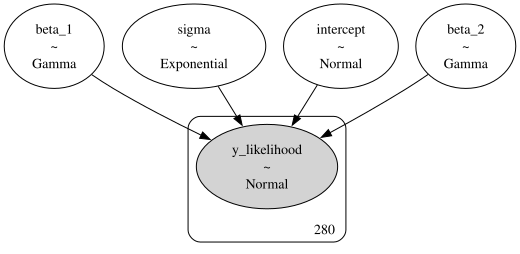

In [ ]:
print("mu shape:", mu.shape)
print("y_train shape:", y_train.shape)
pm.model_to_graphviz(model)

Sampling: [y_likelihood]


Output()

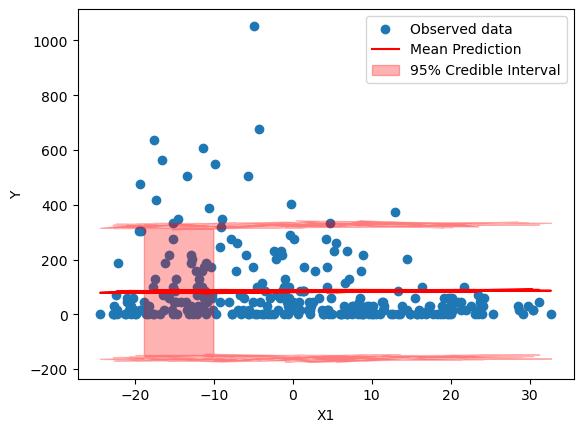

In [ ]:
with model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

y_likelihood_samples = posterior_predictive.posterior_predictive["y_likelihood"].values
samples = y_likelihood_samples.reshape(-1, y_likelihood_samples.shape[-1])  # Shape: (4000, 280)

mean_prediction = np.mean(samples, axis=0)  # Shape: (280,)
lower_bound = np.percentile(samples, 2.5, axis=0)  # 2.5th percentile, shape: (280,)
upper_bound = np.percentile(samples, 97.5, axis=0)




plt.scatter(X1, y, label="Observed data")

# Plot mean prediction
plt.plot(X1, mean_prediction, label="Mean Prediction", color="red")

# Plot 95% credible interval
plt.fill_between(
    X1,
    lower_bound,
    upper_bound,
    color="red",
    alpha=0.3,
    label="95% Credible Interval"
)

# Add labels and legend
plt.xlabel("X1")
plt.ylabel("Y")
plt.legend()
plt.show()


In [ ]:
x = np.linspace(0, 10, 50)  # Fixed x
y_true = 3.0 * x + 1.5  # Deterministic relationship
y_observed = y_true + np.random.normal(0, 1, size=len(x))  # Add noise to simulate observation

# Bayesian model
with pm.Model() as model:
    # Priors for parameters
    slope = pm.Normal("slope", mu=0, sigma=10)
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Deterministic relationship
    mu = slope * x + intercept  # f(x) = slope * x + intercept

    # Likelihood based on observed y
    y_likelihood = pm.Normal("y_likelihood", mu=mu, sigma=sigma, observed=y_observed)

    # Sampling
    trace = pm.sample(1000, return_inferencedata=True)

# Analyze results
import arviz as az
az.plot_trace(trace)
plt.show()

# Posterior predictive check
with model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

plt.scatter(x, y_observed, label="Observed data")
plt.plot(x, np.mean(posterior_predictive.posterior_predictive["y_likelihood"], axis=(0,1)), label="Mean Prediction", color="red")
plt.fill_between(
    x,
    np.percentile(posterior_predictive.posterior_predictive["y_likelihood"], 2.5, axis=(0,1)),
    np.percentile(posterior_predictive.posterior_predictive["y_likelihood"], 97.5, axis=(0,1)),
    color="red",
    alpha=0.3,
    label="95% Credible Interval"
)
plt.legend()
plt.show()
